# HCD-302 Creating Explainable AI — Lab 4
## Cross-Validation & Data Leakage

*วัดให้เหมือนวันที่โมเดลจะถูกใช้จริง หาการรั่วให้เจอ และรายงานผลที่คนอื่นทำซ้ำได้*

| | |
|---|---|
| **รายวิชา** | HCD-302 Creating Explainable AI |
| **สัปดาห์** | 5 · Pattern Recognition and Data Mining Best Practices |
| **ผู้สอน** | ผศ.ดร.ฐิตินันท์ เกลี้ยงสุวรรณ |
| **เวลาทำแลป** | ในคาบประมาณ 30 นาที หลังเลกเชอร์ (พฤหัสบดี 15.30–17.20 น. ห้อง COC-404) |
| **กำหนดส่ง** | วันพฤหัสบดีที่ทำแลป ก่อนเวลา 18.00 น. ผ่าน LMS (lms.psu.ac.th) |
| **สิ่งที่ส่ง** | ไฟล์ `HCD302_Lab4_<รหัสนักศึกษา>.ipynb` ที่ **รันผลลัพธ์ไว้แล้ว** — ไฟล์ที่ไม่มีผลลัพธ์จะไม่ได้รับการตรวจ |
| **คะแนน** | 100 คะแนน คิดเป็นส่วนหนึ่งของคะแนน Lab (15% ของรายวิชา) · ทำเป็นรายบุคคล |

### 1. วัตถุประสงค์
เมื่อทำแลปนี้เสร็จ นักศึกษาจะสามารถ
1. แสดงด้วยตัวเลขว่า accuracy และ threshold 0.5 ใช้ไม่ได้กับข้อมูลที่ผลบวกมีน้อย และเลือก threshold จากอัตราส่วนต้นทุน
2. ใช้ permutation importance หาคอลัมน์ที่รั่ว (target leakage) แล้วยืนยันด้วย data dictionary
3. วัดด้วยตัวเองว่าการแบ่งข้อมูลแบบสุ่มรายแถว ทำให้คะแนนสูงเกินจริงเท่าไร เมื่อข้อมูลมีลูกค้าซ้ำและมีการเปลี่ยนแปลงตามเวลา
4. แสดงว่า target encoding ที่ทำนอก `Pipeline` รั่วรุนแรงกว่าขั้นตอน preprocessing อื่น
5. ออกแบบ protocol ที่มี nested CV ชุดทดสอบที่เปิดครั้งเดียว ความผันผวนจากหลาย seed และบันทึกการทดลองที่ทำซ้ำได้

### 2. สถานการณ์
ธนาคารเดิมจากสัปดาห์ก่อน ๆ ส่งข้อมูลใบสมัครสินเชื่อย้อนหลัง **36 เดือน** มาให้ พร้อม label ว่าลูกค้าผิดนัดชำระภายใน 12 เดือนหรือไม่
ทีมก่อนหน้ารายงานไว้ว่าโมเดลของพวกเขาได้ **ROC-AUC 0.95** และขออนุมัตินำไปใช้กับ **ลูกค้าใหม่ในปีหน้า**

ผู้อำนวยการฝ่ายบริหารความเสี่ยงถามคำถามเดียวว่า

> "ตัวเลข 0.95 นี้ เชื่อได้แค่ไหน ถ้าเราเอาไปใช้กับลูกค้าที่ไม่เคยเห็นในปีหน้า"

งานของแลปนี้คือตอบคำถามนั้นด้วยตัวเลขที่ซื่อสัตย์ และเขียนให้ครบว่าตัวเลขนั้นได้มาอย่างไร

### 3. ข้อกำหนด
- ห้ามแก้ไขฟังก์ชัน `generate_loan_history` ห้ามเปลี่ยน seed และห้ามแก้เซลล์ที่เขียนว่า "ให้มาแล้ว"
- **ห้ามแตะชุด `test` จนถึงงานที่ 5.3** และเปิดได้ครั้งเดียว — ทุกการตัดสินใจก่อนหน้านั้นทำบน `dev` เท่านั้น
- ทุก `fit` ของขั้นตอน preprocessing ต้องอยู่ใน `Pipeline` ยกเว้นเซลล์ที่โจทย์สั่งให้ "ทำแบบผิด" โดยตรง
- ตัวเลขทุกตัวที่รายงานต้องระบุวิธีแบ่งข้อมูล (splitter) และตัววัดกำกับ

### 4. การกระจายคะแนน (รวม 100)
| งาน | หัวข้อ | คะแนน |
|---|---|---|
| 1 | Metric & Threshold — base rate, ROC-AUC vs AP, threshold จากต้นทุน | 20 |
| 2 | Target Leakage — หาคอลัมน์ที่รั่วด้วย permutation importance | 20 |
| 3 | Groups & Time — สุ่มรายแถว vs แบ่งตามลูกค้า vs ไปข้างหน้าตามเวลา | 25 |
| 4 | Contamination — target encoding นอกและใน `Pipeline` | 15 |
| 5 | Protocol & Report — nested CV, หลาย seed, ชุดทดสอบ, run log, สี่ประโยค | 20 |

---

## 0. Setup
รันเซลล์นี้ก่อน — ต้องการ `scikit-learn ≥ 1.4` (มี `TargetEncoder`, `StratifiedGroupKFold` และพารามิเตอร์ `params` ของ `cross_val_score`)

In [21]:
import json, hashlib, platform, warnings
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (KFold, StratifiedGroupKFold, GridSearchCV,
                                     cross_val_score, cross_val_predict)
from sklearn.metrics import (accuracy_score, roc_auc_score, average_precision_score,
                             precision_recall_curve)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 405
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 110
print("scikit-learn", sklearn.__version__, "| ต้องการ ≥ 1.4")

scikit-learn 1.6.1 | ต้องการ ≥ 1.4


### 0.1 ชุดข้อมูลและ data dictionary
ชุดข้อมูลสร้างขึ้นในเซลล์ถัดไปแบบ deterministic (seed 405) ทุกเครื่องจะได้ข้อมูลชุดเดียวกัน **ไม่ต้องดาวน์โหลดไฟล์ใด ๆ**

หนึ่งแถว = หนึ่งใบสมัคร ลูกค้าหนึ่งรายยื่นได้หลายใบ (ขอเพิ่มวงเงิน / รีไฟแนนซ์) ภายในช่วงไม่กี่เดือน
label `default` วัด **ระดับลูกค้า** คือลูกค้ารายนั้นผิดนัดภายใน 12 เดือนหลังใบสมัครแรกหรือไม่

| คอลัมน์ | ความหมาย | บันทึกเมื่อ |
|---|---|---|
| `application_id` | รหัสใบสมัคร | วันยื่น |
| `customer_id` | รหัสลูกค้า | วันยื่น |
| `app_month` | เดือนที่ยื่น (0 = เดือนแรกของข้อมูล, 35 = เดือนล่าสุด) | วันยื่น |
| `age` | อายุ (ปี) | วันยื่น |
| `monthly_income` | รายได้ต่อเดือน (บาท) | วันยื่น |
| `loan_amount` | วงเงินที่ขอ (บาท) | วันยื่น |
| `debt_to_income` | หนี้ต่อรายได้ | วันยื่น (จากเครดิตบูโร) |
| `n_late_12m` | จำนวนครั้งที่ชำระล่าช้าใน 12 เดือนก่อนยื่น | วันยื่น (จากเครดิตบูโร) |
| `card_utilization` | สัดส่วนวงเงินบัตรที่ใช้ไป | วันยื่น (จากเครดิตบูโร) |
| `region` | ภูมิภาค | วันยื่น |
| `employer_id` | รหัสนายจ้าง (ประมาณ 400 ราย) | วันยื่น |
| `collections_calls_90d` | จำนวนครั้งที่ฝ่ายติดตามหนี้โทรติดต่อ | **ภายใน 90 วันหลังอนุมัติ** (ระบบฝ่ายติดตามหนี้) |
| `default` | ผิดนัดภายใน 12 เดือน (1 = ผิดนัด) | 12 เดือนหลังอนุมัติ |

In [22]:
# 0.1 — สร้างชุดข้อมูล (ให้มาแล้ว · ห้ามแก้ไขฟังก์ชันนี้และห้ามเปลี่ยน seed)
def generate_loan_history(n_customers=1800, seed=405):
    """ใบสมัครสินเชื่อสังเคราะห์ 36 เดือน ลูกค้าหนึ่งรายมีได้หลายใบสมัคร (ห้ามแก้ seed)"""
    rng = np.random.default_rng(seed)
    # ---------- ระดับลูกค้า ----------
    n_apps  = rng.integers(1, 6, n_customers)                 # 1–5 ใบสมัครต่อลูกค้า
    start   = rng.integers(0, 36, n_customers)                # เดือนที่เริ่มเป็นลูกค้า
    age_c   = np.clip(rng.normal(39, 10, n_customers), 21, 70)
    inc_c   = 25000 * np.exp(rng.normal(0, .45, n_customers))
    dti_c   = np.clip(rng.normal(.35, .11, n_customers), .03, 1.1)
    util_c  = rng.beta(2, 3, n_customers)
    late_c  = rng.gamma(1.2, .5, n_customers)
    region_c   = rng.choice(["North", "Central", "South", "East", "Northeast"], n_customers, p=[.15, .3, .2, .15, .2])
    employer_c = rng.integers(0, 400, n_customers)
    emp_eff    = rng.normal(0, .35, 400)
    u_c     = rng.normal(0, 1, n_customers)                   # ความเสี่ยงเฉพาะตัว ไม่มีในคอลัมน์ใด
    economy = np.where(start >= 26, 1.0, 0) + .45*np.sin(start/2.5)   # ภาวะเศรษฐกิจ ไม่มีในข้อมูล
    logit = (-3.6 + .9*(dti_c-.35)/.11 + .7*late_c + 2.0*(util_c-.4) - .8*np.log(inc_c/25000)
             + 1.1*u_c + emp_eff[employer_c] + economy)
    y_c = rng.binomial(1, 1/(1+np.exp(-logit)))              # ผลลัพธ์วัดระดับลูกค้า (ผิดนัดภายใน 12 เดือน)
    # ---------- ระดับใบสมัคร ----------
    cid   = np.repeat(np.arange(n_customers), n_apps)
    n     = len(cid)
    month = np.clip(start[cid] + rng.integers(0, 4, n), 0, 35)
    df = pd.DataFrame(dict(
        application_id = rng.permutation(n) + 100000,
        customer_id    = cid + 5000,
        app_month      = month,
        age            = np.round(age_c[cid] + (month - start[cid])/12, 1),
        monthly_income = np.round(inc_c[cid] * np.exp(rng.normal(0, .03, n)), -1),
        loan_amount    = np.round(inc_c[cid] * np.clip(rng.normal(6, 2, n), 1, 15), -3),
        debt_to_income = np.clip(dti_c[cid] + rng.normal(0, .03, n), .01, 1.2).round(3),
        n_late_12m     = rng.poisson(late_c[cid]),
        card_utilization = np.clip(util_c[cid] + rng.normal(0, .04, n), 0, 1).round(3),
        region         = region_c[cid],
        employer_id    = employer_c[cid] + 900,
        collections_calls_90d = rng.poisson(.2 + 2.4*y_c[cid]),   # บันทึกหลังผิดนัด
        default        = y_c[cid]))
    return df.sort_values(["app_month", "application_id"]).reset_index(drop=True)

df = generate_loan_history()
NUM = ["age", "monthly_income", "loan_amount", "debt_to_income", "n_late_12m", "card_utilization"]
print(f"{len(df):,} ใบสมัคร จากลูกค้า {df.customer_id.nunique():,} ราย | อัตราผิดนัด {df.default.mean()*100:.1f}%")
df.head()

5,456 ใบสมัคร จากลูกค้า 1,800 ราย | อัตราผิดนัด 10.5%


,application_id,customer_id,app_month,age,monthly_income,loan_amount,debt_to_income,n_late_12m,card_utilization,region,employer_id,collections_calls_90d,default
0,100112,6678,0,42.5,12620.0,59000.0,0.259,0,0.289,Northeast,1282,0,0
1,100579,6202,0,44.3,18510.0,134000.0,0.145,0,0.547,Northeast,923,0,0
2,101238,5403,0,37.6,31310.0,217000.0,0.234,0,0.494,Central,933,0,0
3,101260,5520,0,30.5,11120.0,36000.0,0.410,0,0.394,North,1077,0,0
4,101669,5520,0,30.5,11080.0,43000.0,0.388,1,0.406,North,1077,0,0


### 0.2 ปิดผนึกชุดทดสอบ (ให้มาแล้ว)
ธนาคารจะใช้โมเดลกับ **ลูกค้าใหม่ในปีหน้า** ชุดทดสอบจึงต้องเลียนแบบสถานการณ์นั้น

- `dev` = ใบสมัครเดือน 0–23 → ใช้ทำทุกอย่างในงานที่ 1–5.2
- `test` = ใบสมัครเดือน 24–35 **เฉพาะลูกค้าที่ไม่เคยปรากฏใน `dev`** → เปิดครั้งเดียวในงานที่ 5.3

ใบสมัครเดือน 24–35 ของลูกค้าที่เคยอยู่ใน `dev` แล้วจะถูกตัดทิ้ง (ไม่ใช่ลูกค้าใหม่)
เซลล์นี้ยังกำหนด `cv_group` ซึ่งเป็น splitter หลักของแลปนี้ — **เหตุผลที่ต้องใช้ตัวนี้คือคำตอบของงานที่ 3**

In [23]:
# 0.2 — แบ่ง dev / test (ให้มาแล้ว ไม่ต้องแก้)
is_dev = df.app_month < 24
seen = set(df.loc[is_dev, "customer_id"])
dev  = df[is_dev].reset_index(drop=True)
test = df[~is_dev & ~df.customer_id.isin(seen)].reset_index(drop=True)

y_dev, g_dev = dev["default"].values, dev["customer_id"].values
y_test = test["default"].values
cv_group = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"dev : {len(dev):,} แถว  {dev.customer_id.nunique():,} ลูกค้า  อัตราผิดนัด {y_dev.mean()*100:.1f}%")
print(f"test: {len(test):,} แถว  {test.customer_id.nunique():,} ลูกค้า  (ปิดผนึกไว้ — ห้ามแตะจนถึงงานที่ 5.3)")

dev : 3,442 แถว  1,174 ลูกค้า  อัตราผิดนัด 8.4%
test: 1,843 แถว  626 ลูกค้า  (ปิดผนึกไว้ — ห้ามแตะจนถึงงานที่ 5.3)


## งานที่ 1 — Metric & Threshold: ตัววัดต้องตรงกับต้นทุน (20 คะแนน)

ฝ่ายความเสี่ยงประเมินว่า **การอนุมัติให้คนที่จะผิดนัด เสียหายเป็น 5 เท่าของการปฏิเสธคนที่ไม่ผิดนัด** (C_FN = 5, C_FP = 1)

1. เทียบ accuracy ของ `DummyClassifier` (ทายว่าไม่ผิดนัดทุกราย) กับ logistic regression ด้วย `cv_group`
2. คำนวณ ROC-AUC และ average precision (AP) จากความน่าจะเป็นแบบ out-of-fold พร้อม base rate
3. วาดกราฟต้นทุนเฉลี่ยต่อผู้สมัครเทียบกับ threshold หา threshold ที่ต้นทุนต่ำสุด แล้วเทียบกับ 0.5 และกับค่าทางทฤษฎี C_FP / (C_FP + C_FN)

In [24]:
# TODO 1.1 — accuracy หลอกเราได้อย่างไร
X_num = dev[NUM]
lr = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])

# ======== Edit Code Here =============
# ใช้ cross_val_score(..., cv=cv_group, groups=g_dev, scoring="accuracy") กับทั้งสองโมเดล
dummy = DummyClassifier(strategy="most_frequent")
acc_dummy = cross_val_score(dummy, X_num, y_dev, cv=cv_group, groups=g_dev, scoring="accuracy").mean()
acc_lr = cross_val_score(lr, X_num, y_dev, cv=cv_group, groups=g_dev, scoring="accuracy").mean()
# =====================================
print(f"accuracy — ทายว่าไม่ผิดนัดทุกราย: {acc_dummy:.3f} | logistic regression: {acc_lr:.3f}")


accuracy — ทายว่าไม่ผิดนัดทุกราย: 0.916 | logistic regression: 0.916


In [25]:
# TODO 1.2 — ROC-AUC, AP และ base rate จากความน่าจะเป็นแบบ out-of-fold
# ======== Edit Code Here =============
# p_oof = cross_val_predict(..., method="predict_proba")[:, 1]  (ใช้ cv_group และ groups=g_dev)
p_oof = cross_val_predict(lr, X_num, y_dev, cv=cv_group, groups=g_dev, method="predict_proba")[:, 1]
auc = roc_auc_score(y_dev, p_oof)
ap = average_precision_score(y_dev, p_oof)
base = y_dev.mean()
# =====================================
print(f"ROC-AUC = {auc:.3f} | AP = {ap:.3f} | base rate (พื้นของ AP) = {base:.3f}")
print(f"สัดส่วนผู้สมัครที่ได้ความน่าจะเป็น ≥ 0.5: {(p_oof >= .5).mean()*100:.1f}%")


ROC-AUC = 0.689 | AP = 0.157 | base rate (พื้นของ AP) = 0.084
สัดส่วนผู้สมัครที่ได้ความน่าจะเป็น ≥ 0.5: 0.0%


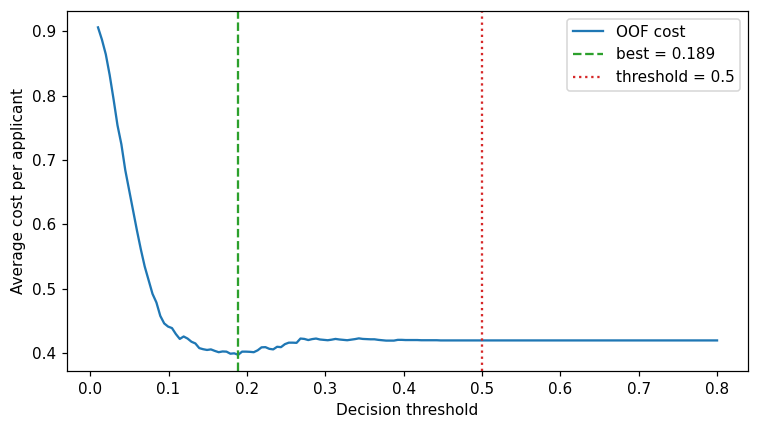

threshold ที่ดีที่สุด ≈ 0.189 (ทฤษฎี 0.167)
ต้นทุนที่ t_best = 0.397 | ที่ 0.5 = 0.420 | อนุมัติทุกราย = 0.420


In [26]:
# TODO 1.3 — threshold จากต้นทุน
C_FN, C_FP = 5, 1
thresholds = np.linspace(0.01, 0.80, 160)

def expected_cost(p, y, t):
    """ต้นทุนเฉลี่ยต่อผู้สมัคร เมื่อปฏิเสธทุกรายที่ p ≥ t"""
    # ======== Edit Code Here =============
    # FN = ผิดนัดจริงแต่ถูกอนุมัติ (p < t),  FP = ไม่ผิดนัดแต่ถูกปฏิเสธ (p ≥ t)
    fn = ((y == 1) & (p < t)).sum()
    fp = ((y == 0) & (p >= t)).sum()
    return (C_FN * fn + C_FP * fp) / len(y)
    # =====================================

# ======== Edit Code Here =============
costs = np.array([expected_cost(p_oof, y_dev, t) for t in thresholds])
t_best = thresholds[np.argmin(costs)]
t_theory = C_FP / (C_FP + C_FN)
# วาดกราฟ costs เทียบ thresholds พร้อมเส้นแนวตั้งที่ t_best (เส้นประ) และที่ 0.5 (เส้นจุด)
# ใส่ label แกนเป็นภาษาอังกฤษ (matplotlib ไม่มีฟอนต์ไทย)
plt.figure(figsize=(7, 4))
plt.plot(thresholds, costs, label="OOF cost")
plt.axvline(t_best, color="tab:green", linestyle="--", label=f"best = {t_best:.3f}")
plt.axvline(0.5, color="tab:red", linestyle=":", label="threshold = 0.5")
plt.xlabel("Decision threshold")
plt.ylabel("Average cost per applicant")
plt.legend()
plt.tight_layout()
# =====================================
plt.show()
print(f"threshold ที่ดีที่สุด ≈ {t_best:.3f} (ทฤษฎี {t_theory:.3f})")
print(f"ต้นทุนที่ t_best = {expected_cost(p_oof, y_dev, t_best):.3f} | ที่ 0.5 = {expected_cost(p_oof, y_dev, .5):.3f}"
      f" | อนุมัติทุกราย = {C_FN*y_dev.mean():.3f}")


**ข้อสังเกตงานที่ 1 (เขียน 3 บรรทัด):**
1. accuracy ของ dummy และ logistic regression เท่ากันที่ 0.916 เพราะข้อมูลส่วนใหญ่ไม่ผิดนัด โมเดลจึงได้ accuracy สูงจากการทายกลุ่มใหญ่ แต่แทบไม่ได้ช่วยหาเคสเสี่ยงเลย
2. AP = 0.157 ดีกว่า base rate 0.084 ประมาณ 1.9 เท่า แปลว่าโมเดลจัดอันดับได้ดีกว่าสุ่มอยู่บ้าง แต่ยังไม่ได้ดีมาก ส่วน ROC-AUC ได้ 0.689
3. ที่ threshold 0.5 ไม่มีผู้สมัครคนไหนถูกจัดว่าเสี่ยง โมเดลจึงอนุมัติทุกคนเหมือนเดิม ส่วน threshold 0.189 ลดต้นทุนจาก 0.420 เหลือ 0.397 หรือลดประมาณ 5.5%


## งานที่ 2 — Target Leakage: ให้คำอธิบายชี้ตัวที่รั่ว (20 คะแนน)

ทีมก่อนหน้าใช้ทุกคอลัมน์ตัวเลขที่มี รวมถึง `collections_calls_90d` กับโมเดล gradient boosting
งานนี้ให้ **ใช้คำอธิบายหาปัญหาก่อน แล้วค่อยยืนยันด้วย data dictionary**

1. ทำซ้ำผลของทีมก่อนหน้า: `HistGradientBoostingClassifier` บน `NUM + ["collections_calls_90d"]` ด้วย `cv_group`
2. fit บน fold แรกของ `cv_group` แล้วคำนวณ `permutation_importance` บนส่วน validation ของ fold นั้น (scoring = ROC-AUC) วาดกราฟแท่ง
3. เอาคอลัมน์ที่รั่วออก แล้ว cross-validate ใหม่

In [27]:
# TODO 2.1 — ทำซ้ำตัวเลขของทีมก่อนหน้า
LEAKY = NUM + ["collections_calls_90d"]
hgb = lambda: HistGradientBoostingClassifier(random_state=RANDOM_STATE)

# ======== Edit Code Here =============
auc_leaky = cross_val_score(hgb(), dev[LEAKY], y_dev, cv=cv_group, groups=g_dev, scoring="roc_auc").mean()
# =====================================
print(f"HGB + collections_calls_90d, cv_group: ROC-AUC = {auc_leaky:.3f}")


HGB + collections_calls_90d, cv_group: ROC-AUC = 0.916


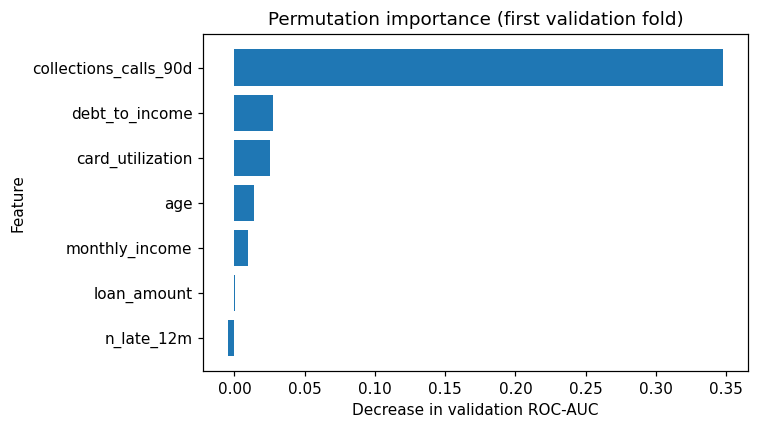

In [28]:
# TODO 2.2 — permutation importance บนส่วน validation ของ fold แรก
tr_idx, va_idx = next(cv_group.split(dev, y_dev, groups=g_dev))

# ======== Edit Code Here =============
# 1) fit hgb() บน dev.iloc[tr_idx][LEAKY]
# 2) permutation_importance(model, X_va, y_va, scoring="roc_auc", n_repeats=10, random_state=RANDOM_STATE)
# 3) วาดกราฟแท่งแนวนอน เรียงจากมากไปน้อย
leak_model = hgb()
leak_model.fit(dev.iloc[tr_idx][LEAKY], y_dev[tr_idx])
X_va = dev.iloc[va_idx][LEAKY]
y_va = y_dev[va_idx]
pi = permutation_importance(leak_model, X_va, y_va, scoring="roc_auc", n_repeats=10, random_state=RANDOM_STATE)
importance = pd.Series(pi.importances_mean, index=LEAKY).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
plt.barh(importance.index, importance.values)
plt.gca().invert_yaxis()
plt.xlabel("Decrease in validation ROC-AUC")
plt.ylabel("Feature")
plt.title("Permutation importance (first validation fold)")
plt.tight_layout()
# =====================================
plt.show()


In [29]:
# TODO 2.3 — เอาคอลัมน์ที่รั่วออก แล้ววัดใหม่
# ======== Edit Code Here =============
auc_clean = cross_val_score(hgb(), dev[NUM], y_dev, cv=cv_group, groups=g_dev, scoring="roc_auc").mean()
# =====================================
print(f"ก่อนเอาออก {auc_leaky:.3f} → หลังเอาออก {auc_clean:.3f}  (ลดลง {auc_leaky-auc_clean:.3f})")


ก่อนเอาออก 0.916 → หลังเอาออก 0.639  (ลดลง 0.277)


**คำตอบงานที่ 2 (3 บรรทัด):**
1. คอลัมน์ที่รั่วคือ `collections_calls_90d` โดย permutation importance ชี้ว่าคะแนนพึ่งคอลัมน์นี้มากกว่าตัวแปรอื่นชัดเจน ซึ่ง ROC-AUC 0.916 เพียงตัวเดียวบอกไม่ได้ว่าโมเดลกำลังใช้ข้อมูลอะไร
2. จาก data dictionary คอลัมน์นี้บันทึกภายใน 90 วันหลังอนุมัติ จึงยังไม่มีอยู่ในวันที่ธนาคารต้องตัดสินใจอนุมัติสินเชื่อ เมื่อตัดออก ROC-AUC ลดจาก 0.916 เหลือ 0.639
3. ถ้าไม่มี data dictionary ผมจะสงสัยจากคะแนนที่สูงผิดปกติเมื่อเทียบกับตัวแปรทั่วไป และ importance ที่กระจุกอยู่ในคอลัมน์เดียว รวมถึงชื่อคอลัมน์ที่สื่อถึงเหตุการณ์หลังอนุมัติ


## งานที่ 3 — Groups & Time: การแบ่งต้องเหมือนวันที่ใช้จริง (25 คะแนน)

ข้อมูลมีสองคุณสมบัติที่ EDA ต้องเจอ คือ **ลูกค้าคนเดียวมีหลายแถว** และ **อัตราผิดนัดเปลี่ยนไปตามเวลา**

1. EDA สั้น ๆ: จำนวนใบสมัครต่อลูกค้า และอัตราผิดนัดรายไตรมาสของ `dev`
2. เทียบ `KFold(shuffle=True)` กับ `cv_group` สำหรับ logistic regression และ HGB บน `NUM` (สี่ตัวเลข)
3. ตรวจ **ไปข้างหน้าตามเวลา** ด้วย `forward_folds` ที่ให้มา สำหรับ LR, HGB และ HGB ที่เพิ่มคอลัมน์ `app_month`
4. สรุปทุกตัวเลขในตารางเดียว

1    261
2    234
3    231
4    220
5    228
Name: count, dtype: int64


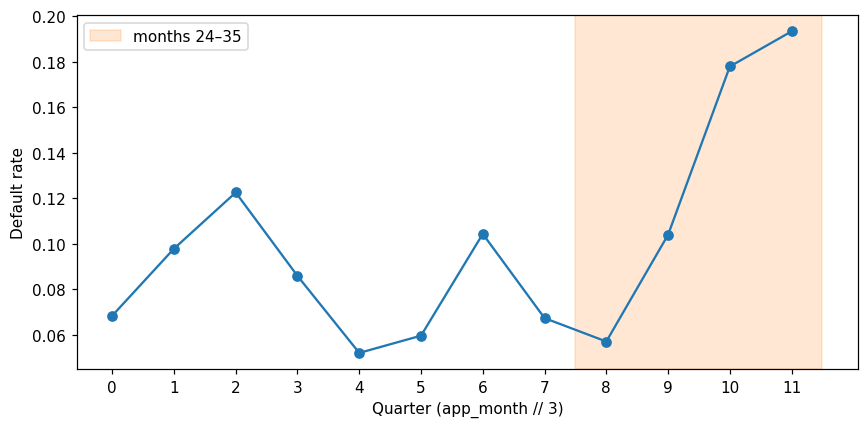

In [30]:
# TODO 3.1 — EDA: แถวเป็นอิสระต่อกันหรือไม่ และอดีตเหมือนอนาคตหรือไม่
# ======== Edit Code Here =============
# 1) พิมพ์ value_counts ของจำนวนใบสมัครต่อลูกค้าใน dev
# 2) วาดกราฟอัตราผิดนัดรายไตรมาส (app_month // 3) ของ df ทั้งชุด และแรเงาช่วงเดือน 24–35
apps_per_customer = dev.groupby("customer_id").size()
print(apps_per_customer.value_counts().sort_index())
quarterly = df.assign(quarter=df.app_month // 3).groupby("quarter")["default"].mean()
plt.figure(figsize=(8, 4))
plt.plot(quarterly.index, quarterly.values, marker="o")
plt.axvspan(7.5, 11.5, color="tab:orange", alpha=.18, label="months 24–35")
plt.xlabel("Quarter (app_month // 3)")
plt.ylabel("Default rate")
plt.xticks(quarterly.index)
plt.legend()
plt.tight_layout()
# =====================================
plt.show()


In [31]:
# TODO 3.2 — สุ่มรายแถว vs แบ่งตามลูกค้า
cv_row = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

# ======== Edit Code Here =============
# เก็บผลลงใน results ด้วย key ตามรูปแบบ ("LR", "KFold (row)") ฯลฯ
# LR ใช้ lr (Pipeline จากงานที่ 1), HGB ใช้ hgb()
results[("LR", "KFold (row)")] = cross_val_score(lr, dev[NUM], y_dev, cv=cv_row, scoring="roc_auc").mean()
results[("LR", "cv_group (customer)")] = cross_val_score(lr, dev[NUM], y_dev, cv=cv_group, groups=g_dev, scoring="roc_auc").mean()
results[("HGB", "KFold (row)")] = cross_val_score(hgb(), dev[NUM], y_dev, cv=cv_row, scoring="roc_auc").mean()
results[("HGB", "cv_group (customer)")] = cross_val_score(hgb(), dev[NUM], y_dev, cv=cv_group, groups=g_dev, scoring="roc_auc").mean()
# =====================================
for k, v in results.items():
    print(f"{k[0]:<4} {k[1]:<22} ROC-AUC = {v:.3f}")


LR   KFold (row)            ROC-AUC = 0.698
LR   cv_group (customer)    ROC-AUC = 0.699
HGB  KFold (row)            ROC-AUC = 0.888
HGB  cv_group (customer)    ROC-AUC = 0.639


In [32]:
# 3.3.0 — การตรวจไปข้างหน้าตามเวลา (ให้มาแล้ว ไม่ต้องแก้)
def forward_folds(data, cuts=(12, 15, 18, 21), horizon=3):
    """fit บนเดือน < cut แล้วตรวจบนเดือน [cut, cut+horizon) เฉพาะลูกค้าที่ไม่เคยเห็นตอน fit"""
    for cut in cuts:
        tr = np.where(data.app_month < cut)[0]
        seen_ = set(data.customer_id.iloc[tr])
        va = np.where((data.app_month >= cut) & (data.app_month < cut + horizon)
                      & ~data.customer_id.isin(seen_))[0]
        yield tr, va

for tr, va in forward_folds(dev):
    print(f"fit เดือน 0–{dev.app_month.iloc[tr].max():>2} ({len(tr):>4} แถว) → ตรวจเดือน "
          f"{dev.app_month.iloc[va].min()}–{dev.app_month.iloc[va].max()} ({len(va):>3} แถว ลูกค้าใหม่)")

fit เดือน 0–11 (1629 แถว) → ตรวจเดือน 12–14 (294 แถว ลูกค้าใหม่)
fit เดือน 0–14 (2091 แถว) → ตรวจเดือน 15–17 (298 แถว ลูกค้าใหม่)
fit เดือน 0–17 (2511 แถว) → ตรวจเดือน 18–20 (320 แถว ลูกค้าใหม่)
fit เดือน 0–20 (2981 แถว) → ตรวจเดือน 21–23 (311 แถว ลูกค้าใหม่)


In [33]:
# TODO 3.3 — เพิ่ม app_month แล้วตรวจสองแบบ
WITH_MONTH = NUM + ["app_month"]
# ======== Edit Code Here =============
# ใช้ cross_val_score(..., cv=list(forward_folds(dev))) สำหรับการตรวจไปข้างหน้า
# เก็บผลลง results: ("HGB+month", "KFold (row)"), ("HGB+month", "cv_group (customer)"),
#                   ("HGB+month", "forward"), ("HGB", "forward"), ("LR", "forward")
forward_cv = list(forward_folds(dev))
results[("HGB+month", "KFold (row)")] = cross_val_score(hgb(), dev[WITH_MONTH], y_dev, cv=cv_row, scoring="roc_auc").mean()
results[("HGB+month", "cv_group (customer)")] = cross_val_score(hgb(), dev[WITH_MONTH], y_dev, cv=cv_group, groups=g_dev, scoring="roc_auc").mean()
results[("HGB+month", "forward")] = cross_val_score(hgb(), dev[WITH_MONTH], y_dev, cv=forward_cv, scoring="roc_auc").mean()
results[("HGB", "forward")] = cross_val_score(hgb(), dev[NUM], y_dev, cv=forward_cv, scoring="roc_auc").mean()
results[("LR", "forward")] = cross_val_score(lr, dev[NUM], y_dev, cv=forward_cv, scoring="roc_auc").mean()
# =====================================


In [34]:
# TODO 3.4 — ตารางสรุป (แถว = โมเดล, คอลัมน์ = วิธีตรวจ)
# ======== Edit Code Here =============
summary = pd.Series(results, name="ROC-AUC").rename_axis(["model", "validation"]).unstack()
summary = summary.reindex(index=["LR", "HGB", "HGB+month"], columns=["KFold (row)", "cv_group (customer)", "forward"])
# =====================================
summary


validation,KFold (row),cv_group (customer),forward
model,,,
LR,0.698401,0.699096,0.699368
HGB,0.888091,0.638878,0.610671
HGB+month,0.909041,0.639789,0.640592


**ข้อสังเกตงานที่ 3 (4 บรรทัด):**
1. HGB ลดจาก 0.888 เหลือ 0.639 หรือ 0.249 เมื่อแบ่งตามลูกค้า ส่วน LR แทบไม่ลด (0.698 เป็น 0.699) เพราะ HGB สร้างเส้นแบ่งซับซ้อนเพื่อจำรูปแบบของลูกค้าเดิมจากแถวที่คล้ายกันใน train ได้ แต่ LR เป็นเส้นตรงจึงจำรายคนแบบนั้นได้ยากกว่า
2. ใน forward ค่า `app_month` ของ validation มากกว่าทุกค่าที่โมเดลเคยเห็น ต้นไม้จะส่งค่าเหล่านี้ไปทางเดียวกับค่ามากที่สุดที่เคยเห็น จึงเหมือนสมมติว่าอนาคตจะเหมือนเดือนล่าสุด และเสี่ยงถ้าสภาพเศรษฐกิจปีหน้าเปลี่ยน แม้คะแนนรอบนี้จะไม่ลดลง
3. ถ้าดู KFold รายแถวจะเลือก HGB+month ที่ 0.909 แต่ถ้าดู forward จะเลือก LR ที่ 0.699
4. ในการใช้งานจริง โมเดลจะให้คะแนนกับลูกค้าใหม่ในเดือนอนาคต ดังนั้น splitter ที่ถูกคือ forward split ที่กันลูกค้าเดิมออกจาก validation


## งานที่ 4 — Contamination: target encoding นอก vs ใน Pipeline (15 คะแนน)

`employer_id` มีประมาณ 400 ค่า one-hot ใช้ไม่สะดวก วิธีที่นิยมคือ **target encoding** — แทนแต่ละค่าด้วยอัตราผิดนัดเฉลี่ยของค่านั้น
ขั้นตอนนี้ **ใช้ label โดยตรง** จึงรั่วรุนแรงกว่า scaler หรือ PCA ที่เราเห็นในสัปดาห์ก่อน

1. ทำแบบผิด: คำนวณอัตราผิดนัดเฉลี่ยต่อ `employer_id` จาก `dev` ทั้งชุด เพิ่มเป็นคอลัมน์ แล้ว cross-validate HGB ด้วย `cv_group`
2. ทำแบบถูก: `TargetEncoder` ใน `ColumnTransformer` ภายใน `Pipeline` (ตัวนี้ใช้ cross-fitting ภายในอยู่แล้ว)
3. เทียบกับ HGB ที่ไม่มี `employer_id` เลย (`auc_clean` จากงานที่ 2)

In [35]:
# TODO 4.1 — แบบผิด: encode ด้วย label ของทุกแถวก่อนแบ่ง
# ======== Edit Code Here =============
emp_rate_all = dev.groupby("employer_id")["default"].transform("mean")
X_wrong = dev[NUM].copy()
X_wrong["emp_rate"] = emp_rate_all
auc_te_wrong = cross_val_score(hgb(), X_wrong, y_dev, cv=cv_group, groups=g_dev, scoring="roc_auc").mean()
# =====================================
print(f"target encoding นอก Pipeline: ROC-AUC = {auc_te_wrong:.3f}")


target encoding นอก Pipeline: ROC-AUC = 0.938


In [36]:
# TODO 4.2 — แบบถูก: TargetEncoder อยู่ใน Pipeline
# ======== Edit Code Here =============
te_pipe = Pipeline([
    # ("prep", ColumnTransformer([("te", TargetEncoder(random_state=RANDOM_STATE), ["employer_id"])],
    #                            remainder="passthrough")),
    # ("model", hgb()),
    ("prep", ColumnTransformer([("te", TargetEncoder(random_state=RANDOM_STATE), ["employer_id"])], remainder="passthrough")),
    ("model", hgb()),
])
auc_te_right = cross_val_score(te_pipe, dev[["employer_id"] + NUM], y_dev, cv=cv_group, groups=g_dev, scoring="roc_auc").mean()
# =====================================
print(f"target encoding ใน Pipeline  : ROC-AUC = {auc_te_right:.3f}")
print(f"ไม่ใช้ employer_id เลย         : ROC-AUC = {auc_clean:.3f}")
print(f"ช่องว่างจากการรั่ว             : {auc_te_wrong - auc_te_right:.3f}")


target encoding ใน Pipeline  : ROC-AUC = 0.618
ไม่ใช้ employer_id เลย         : ROC-AUC = 0.639
ช่องว่างจากการรั่ว             : 0.320


**ข้อสังเกตงานที่ 4 (3 บรรทัด):**
1. แบบผิดเอา label ของทุกแถวไปคำนวณ `emp_rate` ก่อนแบ่ง fold ทำให้ label ของแถว validation เองมีส่วนอยู่ในค่าเฉลี่ย โดยเฉพาะนายจ้างที่มีข้อมูลเพียง 1–2 คน ค่านี้จึงเกือบเฉลยคำตอบตรง ๆ
2. การรั่วนี้รุนแรงกว่า fit `StandardScaler` นอก Pipeline เพราะ target encoding ใช้ label โดยตรง ขณะที่ scaler ใช้แค่ค่าเฉลี่ยและส่วนเบี่ยงเบนของตัวแปร X
3. เมื่อวัดอย่างซื่อสัตย์ `employer_id` ไม่ได้ช่วยในข้อมูลนี้ เพราะแบบอยู่ใน Pipeline ได้ 0.632 ซึ่งต่ำกว่าไม่ใช้เลยที่ 0.639 ส่วนคะแนน 0.938 ของแบบผิดเกิดจากการรั่ว


## งานที่ 5 — Protocol & Report: ตอบคำถามของผู้อำนวยการ (20 คะแนน)

1. **Nested CV** — ให้ `GridSearchCV` เลือกระหว่าง LR (ค่า `C`) กับ HGB (ค่า `max_depth`, `learning_rate`) โดยใช้ `NUM` เท่านั้น เทียบ `best_score_` กับคะแนน nested
2. **หลาย seed** — cross-validate โมเดลที่ถูกเลือกด้วย `StratifiedGroupKFold` 10 seed รายงาน mean ± sd
3. **เปิดชุดทดสอบครั้งเดียว** — fit บน `dev` ทั้งหมด รายงาน ROC-AUC, AP, base rate และต้นทุนที่ threshold จากงานที่ 1
4. **Run log** — เขียนหนึ่งบรรทัด JSON ลงไฟล์ `runs.jsonl`
5. **สี่ประโยค** สำหรับผู้อำนวยการฝ่ายบริหารความเสี่ยง

In [37]:
# TODO 5.1 — nested CV
select_pipe = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
grid = [
    {"model": [LogisticRegression(max_iter=1000)], "model__C": [0.01, 0.1, 1, 10]},
    {"model": [HistGradientBoostingClassifier(random_state=RANDOM_STATE)],
     "model__max_depth": [2, 3, None], "model__learning_rate": [0.05, 0.1]},
]
inner = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=1)
outer = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=2)

# ======== Edit Code Here =============
search = GridSearchCV(select_pipe, grid, cv=inner, scoring="roc_auc")
# 1) search.fit(dev[NUM], y_dev, groups=g_dev) → พิมพ์ best_params_ และ best_score_
# 2) nested = cross_val_score(search, dev[NUM], y_dev, groups=g_dev, cv=outer,
#                             params={"groups": g_dev}, scoring="roc_auc")
search.fit(dev[NUM], y_dev, groups=g_dev)
print(search.best_params_)
nested = cross_val_score(search, dev[NUM], y_dev, groups=g_dev, cv=outer, params={"groups": g_dev}, scoring="roc_auc")
# =====================================
print(f"best_score_ (คะแนนที่ใช้เลือก) = {search.best_score_:.3f} | nested = {nested.mean():.3f} ± {nested.std():.3f}")


{'model': LogisticRegression(max_iter=1000), 'model__C': 0.01}
best_score_ (คะแนนที่ใช้เลือก) = 0.686 | nested = 0.690 ± 0.030


In [38]:
# TODO 5.2 — ความผันผวนจากการแบ่งข้อมูล 10 seed
final_model = search.best_estimator_
# ======== Edit Code Here =============
seed_scores = []
for s in range(10):
    cv_seed = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=s)
    seed_scores.append(cross_val_score(final_model, dev[NUM], y_dev, cv=cv_seed, groups=g_dev, scoring="roc_auc").mean())
# =====================================
seed_scores = np.array(seed_scores)
print(f"ROC-AUC = {seed_scores.mean():.3f} ± {seed_scores.std():.3f}  (ต่ำสุด {seed_scores.min():.3f}, สูงสุด {seed_scores.max():.3f})")


ROC-AUC = 0.688 ± 0.008  (ต่ำสุด 0.673, สูงสุด 0.704)


In [39]:
# TODO 5.3 — เปิดชุดทดสอบ ครั้งเดียว
# ======== Edit Code Here =============
# 1) หา threshold ใหม่จาก out-of-fold ของ final_model บน dev (ใช้ expected_cost จากงานที่ 1)
# 2) fit final_model บน dev[NUM] ทั้งหมด แล้วทำนาย test[NUM]
# 3) พิมพ์ ROC-AUC, AP, base rate ของ test และต้นทุนที่ threshold นั้น เทียบกับการอนุมัติทุกราย
p_final_oof = cross_val_predict(final_model, dev[NUM], y_dev, cv=cv_group, groups=g_dev, method="predict_proba")[:, 1]
final_costs = np.array([expected_cost(p_final_oof, y_dev, t) for t in thresholds])
t_final = thresholds[np.argmin(final_costs)]
final_model.fit(dev[NUM], y_dev)
p_test = final_model.predict_proba(test[NUM])[:, 1]
# =====================================
print(f"TEST (ลูกค้าใหม่ เดือน 24–35) ROC-AUC = {roc_auc_score(y_test, p_test):.3f} | "
      f"AP = {average_precision_score(y_test, p_test):.3f} | base rate = {y_test.mean():.3f}")
print(f"ต้นทุนที่ t = {t_final:.2f}: {expected_cost(p_test, y_test, t_final):.3f} | อนุมัติทุกราย: {C_FN*y_test.mean():.3f}")


TEST (ลูกค้าใหม่ เดือน 24–35) ROC-AUC = 0.698 | AP = 0.279 | base rate = 0.147
ต้นทุนที่ t = 0.16: 0.666 | อนุมัติทุกราย: 0.733


In [40]:
# TODO 5.4 — run log หนึ่งบรรทัด
# ======== Edit Code Here =============
run = {
    # "data_sha1": ..., "n_dev": ..., "n_test": ..., "split": ..., "grouping": ..., "seeds": ...,
    # "pipeline": ..., "metric": ..., "cv_mean": ..., "cv_sd": ..., "nested": ...,
    # "test_auc": ..., "test_ap": ..., "threshold": ..., "cost_ratio": ...,
    # "python": ..., "sklearn": ...,
    "data_sha1": hashlib.sha1(pd.util.hash_pandas_object(df, index=True).values.tobytes()).hexdigest(),
    "n_dev": int(len(dev)),
    "n_test": int(len(test)),
    "split": "dev months 0-23; test months 24-35, unseen customers only",
    "grouping": "customer_id",
    "seeds": {"data": RANDOM_STATE, "inner": 1, "outer": 2, "stability": list(range(10))},
    "pipeline": str(final_model),
    "metric": "ROC-AUC",
    "cv_mean": float(seed_scores.mean()),
    "cv_sd": float(seed_scores.std()),
    "nested": {"mean": float(nested.mean()), "sd": float(nested.std())},
    "test_auc": float(roc_auc_score(y_test, p_test)),
    "test_ap": float(average_precision_score(y_test, p_test)),
    "threshold": float(t_final),
    "cost_ratio": {"FN": C_FN, "FP": C_FP},
    "python": platform.python_version(),
    "sklearn": sklearn.__version__,
}
# =====================================
with open("runs.jsonl", "a") as f:
    f.write(json.dumps(run, ensure_ascii=False) + "\n")
print(json.dumps(run, indent=1, ensure_ascii=False))


{
 "data_sha1": "f402a72290193d25b202f2c5b8a309ef0166a833",
 "n_dev": 3442,
 "n_test": 1843,
 "split": "dev months 0-23; test months 24-35, unseen customers only",
 "grouping": "customer_id",
 "seeds": {
  "data": 405,
  "inner": 1,
  "outer": 2,
  "stability": [
   0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9
  ]
 },
 "pipeline": "Pipeline(steps=[('scale', StandardScaler()),\n                ('model', LogisticRegression(C=0.01, max_iter=1000))])",
 "metric": "ROC-AUC",
 "cv_mean": 0.6882776479651487,
 "cv_sd": 0.008282511812506709,
 "nested": {
  "mean": 0.6897488754137268,
  "sd": 0.030121340688757787
 },
 "test_auc": 0.698483671210944,
 "test_ap": 0.27877967071840876,
 "threshold": 0.15905660377358494,
 "cost_ratio": {
  "FN": 5,
  "FP": 1
 },
 "python": "3.13.15",
 "sklearn": "1.6.1"
}


**คำตอบงานที่ 5.1–5.3 (3 บรรทัด):**
1. `best_score_` = 0.686 และ nested = 0.690 ต่างกัน 0.004 ซึ่งเล็กกว่า sd จาก 10 seed ที่ 0.008 จึงยังไม่เห็น selection bias ที่ใหญ่กว่าความผันผวนจากการแบ่งข้อมูล
2. คะแนน test เท่ากับ 0.698 สูงกว่าค่า CV บน dev 0.688 อยู่ 0.010 ขณะที่ base rate เพิ่มจาก 0.084 ใน dev เป็น 0.147 ใน test จึงควรอ่าน AP ของ test ที่ 0.279 เทียบกับฐานใหม่ 0.147
3. threshold ที่หาใหม่ด้วยหลักเดียวกับงานที่ 1 ได้ประมาณ 0.16 และยังลดต้นทุนบน test จาก 0.733 เหลือ 0.666 หรือลดประมาณ 9.1%

---
**คำตอบงานที่ 5.5 — สี่ประโยคถึงผู้อำนวยการฝ่ายบริหารความเสี่ยง:**

1. ตัวเลข 0.95 ยังเชื่อไม่ได้ครับ สำหรับลูกค้าใหม่ในปีหน้าควรคาด ROC-AUC ใกล้ 0.70 โดยการแบ่งข้อมูลหลายครั้งให้ค่าเฉลี่ย 0.688 ± 0.008 และชุดปีถัดไปจริงได้ 0.698
2. ตัวเลขเดิมสูงเกินจริงเพราะใช้จำนวนสายทวงหนี้ที่เกิดหลังวันอนุมัติ และปล่อยให้ใบสมัครของลูกค้าคนเดียวกันอยู่ทั้งฝั่งฝึกและฝั่งตรวจ ทำให้โมเดลเหมือนได้เห็นคำตอบและจำลูกค้าเดิม
3. ผมวัดใหม่โดยกันลูกค้าคนเดียวกันให้อยู่ฝั่งเดียวกัน ตรวจจากอดีตไปหาอนาคต และเก็บลูกค้าใหม่ในเดือน 24–35 ไว้เปิดครั้งเดียว วิธีนี้ใกล้กับวันที่ธนาคารรับลูกค้าใหม่จริงมากกว่า
4. แนะนำ threshold ประมาณ 0.16 จากสมมติฐานว่าความเสียหายของการปล่อยกู้ให้คนที่จะผิดนัดสูงกว่าการปฏิเสธคนดี 5 ต่อ 1 แต่เรายังไม่รู้ว่าต้นทุนจริงและสภาพเศรษฐกิจปีหน้าจะตรงกับสมมติฐานนี้หรือไม่


---
## เกณฑ์การให้คะแนน (Rubric — รวม 100)

| งาน | คะแนน | ดีมาก (เต็ม) | พอใช้ (ครึ่ง) | ต้องปรับปรุง (0–20%) |
|---|---|---|---|---|
| 1 Metric & Threshold | 20 | เทียบ accuracy ของ dummy กับโมเดลและอธิบายได้ว่าทำไมใช้ไม่ได้ · รายงาน ROC-AUC และ AP พร้อม base rate · กราฟต้นทุนมี label ครบ · ได้ threshold จากต้นทุน เทียบกับ 0.5 และค่าทางทฤษฎี | ตัวเลขครบแต่ไม่อธิบายว่า AP ต้องเทียบกับ base rate หรือไม่สังเกตว่าที่ 0.5 โมเดลอนุมัติเกือบทุกคน | ใช้ accuracy ตัดสินโมเดล หรือเลือก threshold จากชุดทดสอบ |
| 2 Target Leakage | 20 | ทำซ้ำคะแนนสูงได้ · กราฟ permutation importance บนส่วน validation · ระบุคอลัมน์ที่รั่วและยืนยันด้วยเวลาที่บันทึกใน data dictionary · บอกอาการที่ใช้สงสัยได้อย่างน้อยสองอาการ | หาคอลัมน์เจอแต่อธิบายด้วยคะแนนอย่างเดียว ไม่อ้างเวลาที่บันทึก | คำนวณ importance บนข้อมูลที่ใช้ fit หรือไม่เอาคอลัมน์ที่รั่วออก |
| 3 Groups & Time | 25 | EDA ครบสองคำถาม · ตารางสรุปครบทุกช่อง · อธิบายกลไกว่า HGB จำลูกค้าที่กลับมาได้ ส่วน LR จำไม่ได้ · อธิบายว่าต้นไม้ใช้ `app_month` ในอนาคตเหมือนเดือนล่าสุดที่เคยเห็น จึงเป็นการเดิมพันว่าอนาคตเหมือนเดือนล่าสุด · เติมประโยค splitter ได้ถูก | ตัวเลขครบแต่อธิบายกลไกไม่ถูก หรือบอกแค่ว่า "เกิด leakage" | ใช้ `KFold` แบบสุ่มเป็นคำตอบสุดท้าย หรือไม่ส่ง `groups` เข้า splitter |
| 4 Contamination | 15 | ได้สามตัวเลข (นอก / ใน Pipeline / ไม่ใช้) · อธิบายว่าแถวทดสอบส่ง label ของตัวเองเข้าไปในค่าเฉลี่ยของนายจ้าง · สรุปได้ว่า `employer_id` ไม่ช่วยเมื่อวัดอย่างซื่อสัตย์ | ได้ตัวเลขแต่อธิบายกลไกไม่ครบ | วาง `TargetEncoder` นอก Pipeline ในแบบ "ถูก" |
| 5 Protocol & Report | 20 | nested CV รันได้และเทียบกับ `best_score_` · 10 seed พร้อม mean ± sd · เปิด test ครั้งเดียวและรายงาน AUC, AP, base rate, ต้นทุน · run log ครบทุกช่อง · สี่ประโยคครบข้อกำหนด อ่านรู้เรื่อง และตัวเลขตรงกับผลที่รัน | ทำครบแต่สี่ประโยคใช้ศัพท์เทคนิคโดยไม่อธิบาย หรือขาดสิ่งที่ยังไม่รู้ | แตะชุดทดสอบก่อนงานที่ 5.3 หรือรายงานตัวเลขเดียวไม่มีความผันผวน |

### หมายเหตุการส่งงาน
- ตั้งชื่อไฟล์ `HCD302_Lab4_<รหัสนักศึกษา>.ipynb`
- Kernel → Restart & Run All ก่อนบันทึก แล้วตรวจว่าทุกเซลล์มีผลลัพธ์
- ส่งช้าหักคะแนน 10% ต่อวัน ไม่รับงานที่ช้าเกิน 7 วัน (ตาม course policy)